In [1]:
import rasterio
import pandas as pd
import numpy as np
import glob
import os

# 1. 路径设置
veg_path = 'G:/Eurasia/prediction_result_20260408_clip3.tif'

# 假设你的时间序列数据存放在不同的文件夹中，使用 glob 获取所有影像路径并排序
# 排序(sorted)很重要，确保特征列是按时间顺序排列的（如 Temp_1, Temp_2 ...）
temp_files = sorted(glob.glob('G:/Eurasia/all/LST/*.tif'))
precip_files = sorted(glob.glob('G:/Eurasia/all/PR/*.tif'))
aridity_files = sorted(glob.glob('G:/Eurasia/all/PDSI/*.tif'))

target_sample_size = 2000  # 为每个植被群系设定的目标抽样上限

with rasterio.open(veg_path) as src_veg:
    veg_data = src_veg.read(1)
    
    # ---------------- 保持原有的分层抽样逻辑完全不变 ----------------
    alliances = np.unique(veg_data)
    alliances = alliances[alliances > 0] 
    
    sampled_coords = []
    veg_vals = []
    
    for alliance in alliances:
        rows, cols = np.where(veg_data == alliance)
        total_pixels = len(rows)
        
        actual_size = min(target_sample_size, total_pixels)
        
        if actual_size > 0:
            sample_indices = np.random.choice(total_pixels, size=actual_size, replace=False)
            sample_rows = rows[sample_indices]
            sample_cols = cols[sample_indices]
            
            coords = [src_veg.xy(r, c) for r, c in zip(sample_rows, sample_cols)]
            sampled_coords.extend(coords)
            # 同步记录对应的植被群系标签，避免后续重新打开植被图提取
            veg_vals.extend([alliance] * actual_size)
    # ----------------------------------------------------------------

# 2. 构建数据字典，初始化为包含群系标签
data_dict = {'Vegetation_Alliance': veg_vals}

# 3. 定义时间序列特征提取函数
def extract_timeseries(file_list, feature_prefix, coords):
    """
    遍历时间序列影像列表，提取坐标点的值，并存入全局字典
    """
    for i, file_path in enumerate(file_list):
        with rasterio.open(file_path) as src:
            # rasterio.sample 会返回每个坐标点的值数组
            vals = [val[0] for val in src.sample(coords)]
            
            # 生成列名，例如 Temp_1, Temp_2...
            col_name = f"{feature_prefix}_{i+1}"
            data_dict[col_name] = vals
            print(f"提取完成: {col_name}")

# 4. 执行多变量、多期影像的批量提取
print(f"总计抽样点数: {len(sampled_coords)}")
print("开始提取时间序列气候数据...")

extract_timeseries(temp_files, 'Temp', sampled_coords)
extract_timeseries(precip_files, 'Precip', sampled_coords)
extract_timeseries(aridity_files, 'Aridity', sampled_coords)

# 5. 构建最终的宽表 DataFrame
df = pd.DataFrame(data_dict)

# 清洗含有 NoData 的无效样本点（如果有的话）
df = df.dropna()

print("\n数据提取完成！DataFrame 结构如下：")
print(df.head())
print(f"数据表维度 (行x列): {df.shape}")

# 可选：将提取结果保存为 CSV，避免下次重复运行提取过程
df.to_csv('G:/Eurasia/alliance_climate_samples.csv', index=False)

总计抽样点数: 376431
开始提取时间序列气候数据...
提取完成: Temp_1
提取完成: Temp_2
提取完成: Temp_3
提取完成: Temp_4
提取完成: Temp_5
提取完成: Temp_6
提取完成: Temp_7
提取完成: Temp_8
提取完成: Temp_9
提取完成: Temp_10
提取完成: Temp_11
提取完成: Temp_12
提取完成: Temp_13
提取完成: Temp_14
提取完成: Temp_15
提取完成: Temp_16
提取完成: Temp_17
提取完成: Temp_18
提取完成: Temp_19
提取完成: Temp_20
提取完成: Temp_21
提取完成: Temp_22
提取完成: Temp_23
提取完成: Temp_24
提取完成: Temp_25
提取完成: Temp_26
提取完成: Temp_27
提取完成: Temp_28
提取完成: Temp_29
提取完成: Temp_30
提取完成: Temp_31
提取完成: Temp_32
提取完成: Temp_33
提取完成: Temp_34
提取完成: Temp_35
提取完成: Temp_36
提取完成: Temp_37
提取完成: Temp_38
提取完成: Temp_39
提取完成: Temp_40
提取完成: Temp_41
提取完成: Temp_42
提取完成: Temp_43
提取完成: Temp_44
提取完成: Temp_45
提取完成: Temp_46
提取完成: Temp_47
提取完成: Precip_1
提取完成: Precip_2
提取完成: Precip_3
提取完成: Precip_4
提取完成: Precip_5
提取完成: Precip_6
提取完成: Precip_7
提取完成: Precip_8
提取完成: Precip_9
提取完成: Precip_10
提取完成: Precip_11
提取完成: Precip_12
提取完成: Aridity_1
提取完成: Aridity_2
提取完成: Aridity_3
提取完成: Aridity_4
提取完成: Aridity_5
提取完成: Aridity_6
提取完成: Aridity_7
提取完成: Aridity_8
提取完成: Ari

正在训练随机森林模型以评估环境驱动力，这可能需要一点时间...
驱动力模型在测试集上的分类准确率: 0.4333

排名前 15 的核心驱动环境因子：
     Feature  Importance
12   Temp_13    0.018337
26   Temp_27    0.018279
18   Temp_19    0.017910
6     Temp_7    0.017879
31   Temp_32    0.017714
40   Temp_41    0.017004
33   Temp_34    0.016882
1     Temp_2    0.016874
35   Temp_36    0.016838
53  Precip_7    0.016742
39   Temp_40    0.016525
25   Temp_26    0.016385
52  Precip_6    0.015999
4     Temp_5    0.015958
42   Temp_43    0.015908


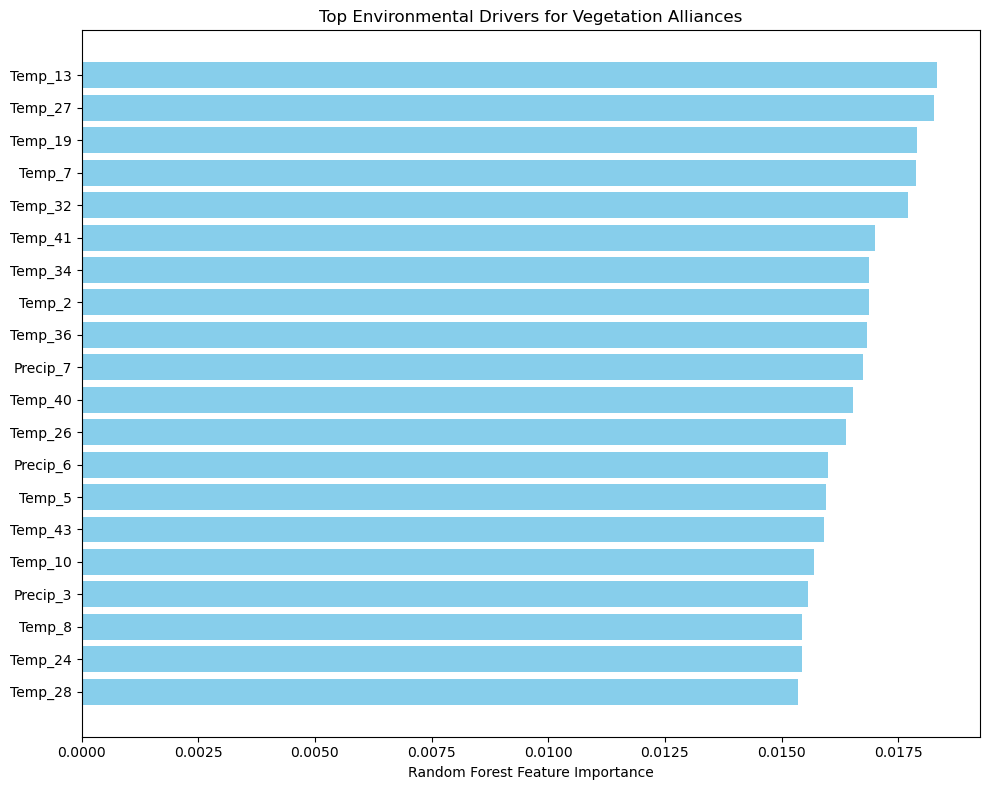

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 假设 df 是你已经成功提取并去除了 NoData 的完整宽表
# 1. 划分特征 (X) 和标签 (y)
X = df.drop(columns=['Vegetation_Alliance'])
y = df['Vegetation_Alliance']

# 划分训练集和测试集（用 20% 的数据验证一下模型靠不靠谱）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 构建并训练随机森林模型
# n_jobs=-1 表示调用所有 CPU 核心并行计算加速
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

print("正在训练随机森林模型以评估环境驱动力，这可能需要一点时间...")
rf_model.fit(X_train, y_train)

# 简单看下准确率，如果准确率极低，说明纯靠气候不足以区分这些群系
accuracy = rf_model.score(X_test, y_test)
print(f"驱动力模型在测试集上的分类准确率: {accuracy:.4f}")

# 3. 提取特征重要性并可视化
importances = rf_model.feature_importances_
feature_names = X.columns

# 将特征名和重要性打包并排序
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n排名前 15 的核心驱动环境因子：")
print(feature_imp_df.head(15))

# 4. 画一张特征重要性的柱状图 (只画前 20 个最重要的)
top_n = 20
subset_imp = feature_imp_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(subset_imp['Feature'][::-1], subset_imp['Importance'][::-1], color='skyblue')
plt.xlabel('Random Forest Feature Importance')
plt.title('Top Environmental Drivers for Vegetation Alliances')
plt.tight_layout()
plt.show()


================ 整体环境因子驱动力排名（按类别汇总） ================
  Variable_Group  Importance
2           Temp    0.662892
1         Precip    0.170014
0        Aridity    0.167094


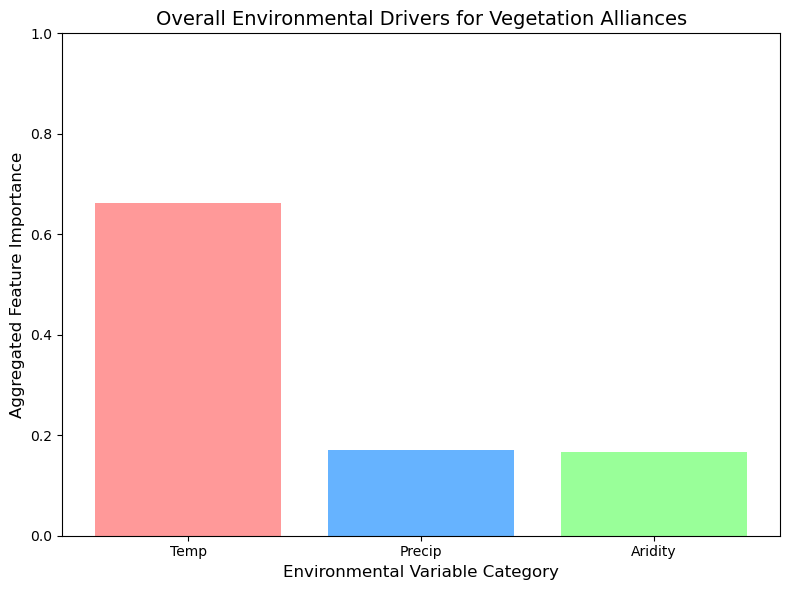

In [3]:
# ================= 以下为你需要追加的新代码 =================

# 1. 提取基础变量名作为新列（去掉下划线和数字）
# 例如：通过 split('_') 把 'Temp_13' 截断成 'Temp'，把 'Precip_7' 截断成 'Precip'
feature_imp_df['Variable_Group'] = feature_imp_df['Feature'].apply(lambda x: x.split('_')[0])

# 2. 按基础变量名分组，并将它们的重要性全部加和 (sum)
grouped_importance = feature_imp_df.groupby('Variable_Group')['Importance'].sum().reset_index()

# 3. 按加总后的总重要性进行降序排列
grouped_importance = grouped_importance.sort_values(by='Importance', ascending=False)

print("\n================ 整体环境因子驱动力排名（按类别汇总） ================")
print(grouped_importance)

# 4. 画一张分类汇总后的柱状图
plt.figure(figsize=(8, 6))
# 选取几个好看的颜色以便区分
colors = ['#ff9999', '#66b3ff', '#99ff99'] 
plt.bar(grouped_importance['Variable_Group'], grouped_importance['Importance'], color=colors[:len(grouped_importance)])

plt.xlabel('Environmental Variable Category', fontsize=12)
plt.ylabel('Aggregated Feature Importance', fontsize=12)
plt.title('Overall Environmental Drivers for Vegetation Alliances', fontsize=14)
plt.ylim(0, 1) # 所有的重要性加起来等于1
plt.tight_layout()
plt.show()